In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from datetime import datetime, timedelta
import dukascopy_python
from dukascopy_python.instruments import INSTRUMENT_FX_MAJORS_EUR_USD

In [6]:
from pathlib import Path

start = datetime(2025, 1, 1)
end = datetime(2025, 12, 31)

parquet_path = Path("raw_ticks_cache.parquet")

In [7]:
raw_ticks = pd.read_parquet(parquet_path)
raw_ticks['mid'] = (raw_ticks['bidPrice']+ raw_ticks['askPrice'])/2
raw_ticks['mid'].head()
d = raw_ticks['mid'].resample('1s').last().ffill()


In [8]:
d = pd.DataFrame(d)
d['log_return'] = np.log(d['mid']/d['mid'].shift(1))

In [9]:
window = "1h"
sq_returns = d['log_return']**2
rv_window = sq_returns.rolling(window).sum()


In [10]:
baseline_adaptive = rv_window.rolling("30D").mean()

In [11]:
variance_ratio_adaptive = rv_window / baseline_adaptive
 
print("Variance ratio (adaptive baseline) stats:")
print(variance_ratio_adaptive.describe(), "\n")

def classify(ratio):
    if pd.isna(ratio):
        return np.nan
    if ratio < 0.5:
        return "calm"
    elif ratio < 1.5:
        return "normal"
    elif ratio < 3.0:
        return "elevated"
    else:
        return "heated"
 
regime = variance_ratio_adaptive.apply(classify)
print("Time spent in each regime (adaptive baseline):")
print(regime.value_counts(normalize=True), "\n")

Variance ratio (adaptive baseline) stats:
count    3.136677e+07
mean     9.788164e-01
std      2.601061e+00
min      0.000000e+00
25%      0.000000e+00
50%      5.037310e-01
75%      1.137813e+00
max      1.665810e+02
Name: log_return, dtype: float64 

Time spent in each regime (adaptive baseline):
log_return
calm        0.497902
normal      0.329793
elevated    0.120395
heated      0.051911
Name: proportion, dtype: float64 



/var/folders/6n/0n62hfmn0wb7slbnjxdhg79c0000gn/T/ipykernel_61386/2219543077.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


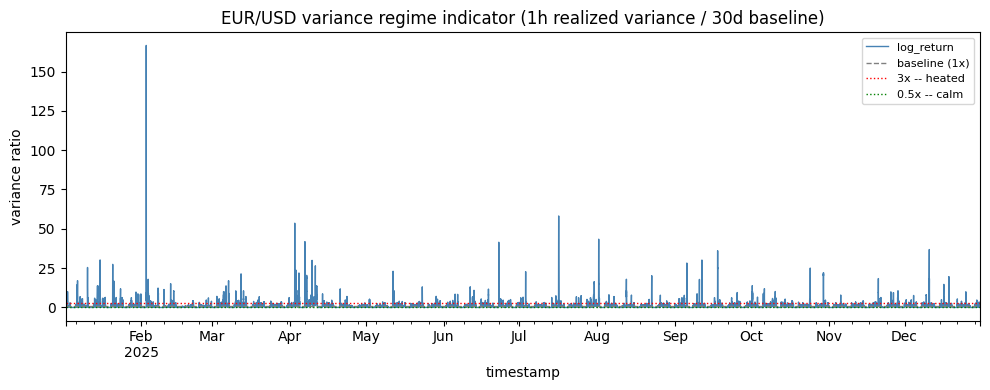

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
variance_ratio_adaptive.plot(ax=ax, lw=1, color="steelblue")
ax.axhline(1.0, color="gray", ls="--", lw=1, label="baseline (1x)")
ax.axhline(3.0, color="red", ls=":", lw=1, label="3x -- heated")
ax.axhline(0.5, color="green", ls=":", lw=1, label="0.5x -- calm")
ax.set_title("EUR/USD variance regime indicator (1h realized variance / 30d baseline)")
ax.set_ylabel("variance ratio")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [13]:
print("Read the ratio directly: 'It is as if information is flowing")
print(f"{variance_ratio_adaptive.iloc[-1]:.1f}x as quickly as normal right now'")
print("(using the most recent value in the series).")

Read the ratio directly: 'It is as if information is flowing
0.4x as quickly as normal right now'
(using the most recent value in the series).


In [14]:
from pathlib import Path

start = datetime(2026, 1, 1)
end = datetime(2026, 3, 31)

parquet_path = Path("raw_ticks_2026.parquet")

if parquet_path.exists():
    raw_ticks_2026 = pd.read_parquet(parquet_path)
    print(f"Loaded {len(raw_ticks):,} ticks from {parquet_path}")
else:
    raw_ticks_2026 = dukascopy_python.fetch(
        instrument=INSTRUMENT_FX_MAJORS_EUR_USD,
        interval=dukascopy_python.INTERVAL_TICK,
        offer_side=dukascopy_python.OFFER_SIDE_BID,
        start=start,
        end=end,
    )
    parquet_path.parent.mkdir(parents=True, exist_ok=True)
    raw_ticks_2026.to_parquet(parquet_path, index=True, compression="snappy")
    print(f"Fetched {len(raw_ticks_2026):,} ticks")
    print(f"Saved parquet: {parquet_path}")

print(f"Columns: {list(raw_ticks_2026.columns)}")
print(f"Range: {raw_ticks_2026.index.min()} -> {raw_ticks_2026.index.max()}")
raw_ticks_2026.head()

Loaded 23,409,558 ticks from raw_ticks_2026.parquet
Columns: ['bidPrice', 'askPrice', 'bidVolume', 'askVolume']
Range: 2026-01-01 22:04:01.135000+00:00 -> 2026-03-30 21:59:54.074000+00:00


,bidPrice,askPrice,bidVolume,askVolume
timestamp,,,,
2026-01-01 22:04:01.135000+00:00,1.17387,1.17532,0.90,0.90
2026-01-01 22:04:37.436000+00:00,1.17414,1.17531,4.50,0.90
2026-01-01 22:05:00.073000+00:00,1.17414,1.17517,0.72,1.53
2026-01-01 22:05:00.283000+00:00,1.17449,1.17523,0.90,1.53
2026-01-01 22:05:01.142000+00:00,1.17449,1.17518,0.90,1.53


In [15]:
raw_ticks = pd.read_parquet(parquet_path)
raw_ticks['mid'] = (raw_ticks['bidPrice']+ raw_ticks['askPrice'])/2
raw_ticks['mid'].head()
d = raw_ticks['mid'].resample('1s').last().ffill()
d = d[d.index.dayofweek < 5]  # drop Sat/Sun (flat-filled, not real trading)

In [16]:
d = pd.DataFrame(d)
d['log_return'] = np.log(d['mid']/d['mid'].shift(1))

In [17]:
window = "1h"
sq_returns = d['log_return']**2
rv_window = sq_returns.rolling(window).sum()
baseline_adaptive = rv_window.rolling("30D").mean()

In [18]:
variance_ratio_adaptive = rv_window / baseline_adaptive
 
print("Variance ratio (adaptive baseline) stats:")
print(variance_ratio_adaptive.describe(), "\n")

def classify(ratio):
    if pd.isna(ratio):
        return np.nan
    if ratio < 0.5:
        return "calm"
    elif ratio < 1.5:
        return "normal"
    elif ratio < 3.0:
        return "elevated"
    else:
        return "heated"
 
regime = variance_ratio_adaptive.apply(classify)
print("Time spent in each regime (adaptive baseline):")
print(regime.value_counts(normalize=True), "\n")

Variance ratio (adaptive baseline) stats:
count    5.356518e+06
mean     1.245198e+00
std      2.842834e+00
min      0.000000e+00
25%      3.644438e-01
50%      6.872497e-01
75%      1.363536e+00
max      8.276552e+01
Name: log_return, dtype: float64 

Time spent in each regime (adaptive baseline):
log_return
normal      0.406441
calm        0.371108
elevated    0.159324
heated      0.063127
Name: proportion, dtype: float64 



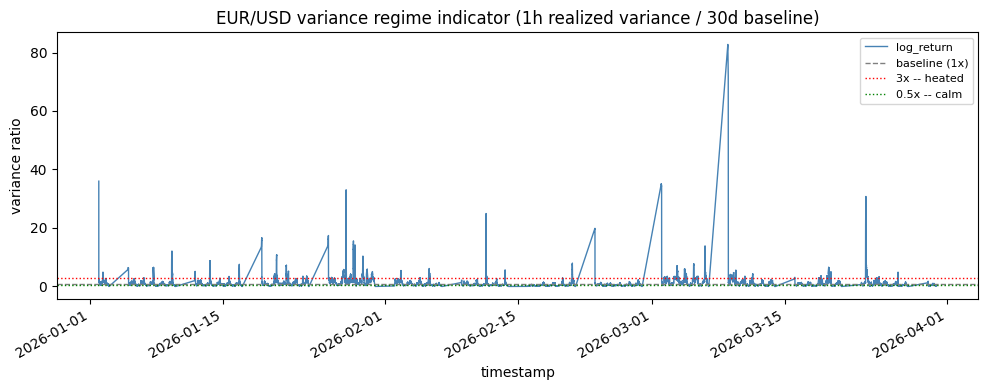

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
variance_ratio_adaptive.plot(ax=ax, lw=1, color="steelblue")
ax.axhline(1.0, color="gray", ls="--", lw=1, label="baseline (1x)")
ax.axhline(3.0, color="red", ls=":", lw=1, label="3x -- heated")
ax.axhline(0.5, color="green", ls=":", lw=1, label="0.5x -- calm")
ax.set_title("EUR/USD variance regime indicator (1h realized variance / 30d baseline)")
ax.set_ylabel("variance ratio")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [25]:
"""
HAR-Return: same HAR kernel structure as the log-HAR-RV cell above (lag1 +
rolling-24h "daily" + rolling-168h "weekly" features, OLS, 80/20 split),
but fit on signed hourly log-returns instead of squared returns. RV only
ever tells you the expected *size* of the next move; regressing on the
raw (signed) return lets the same lag/daily/weekly kernel also pick up
directional persistence (momentum) or mean-reversion, so the forecast
carries both magnitude and sign.

No log-transform here: unlike RV, returns are signed, so log(ret) isn't
defined. Returns are already far less heavy-tailed than squared returns,
so raw-level OLS is the natural fit (this is also why the RV cell had to
log-transform and this one doesn't).
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

ret_hourly = d['log_return'].resample("1h").sum().dropna()

df_r = pd.DataFrame({"ret": ret_hourly})
df_r["ret_lag1"] = df_r["ret"].shift(1)
df_r["ret_daily"] = df_r["ret"].shift(1).rolling(24).mean()
df_r["ret_weekly"] = df_r["ret"].shift(1).rolling(24 * 7).mean()
df_r["ret_target"] = df_r["ret"].shift(-1)
df_r = df_r.dropna()

split_r = int(len(df_r) * 0.8)
train_r, test_r = df_r.iloc[:split_r], df_r.iloc[split_r:]

feature_cols_r = ["ret_lag1", "ret_daily", "ret_weekly"]
X_train_r = sm.add_constant(train_r[feature_cols_r])
y_train_r = train_r["ret_target"]
X_test_r = sm.add_constant(test_r[feature_cols_r], has_constant="add")
y_test_r = test_r["ret_target"]

model_r = sm.OLS(y_train_r, X_train_r).fit()
print(model_r.summary())
print("\nFitted kernel weights (K), return space:")
print(model_r.params, "\n")

# ---- out-of-sample R^2 -----------------------------------------------
test_pred_r = model_r.predict(X_test_r)
ss_res_r = ((y_test_r - test_pred_r) ** 2).sum()
ss_tot_r = ((y_test_r - y_test_r.mean()) ** 2).sum()
oos_r2_r = 1 - ss_res_r / ss_tot_r

print(f"In-sample R^2:      {model_r.rsquared:.4f}")
print(f"Out-of-sample R^2:  {oos_r2_r:.4f}\n")

# ---- directional accuracy: the thing RV could never give you ---------
pred_sign = np.sign(test_pred_r)
actual_sign = np.sign(y_test_r)
nonzero = actual_sign != 0
hit_rate = (pred_sign[nonzero] == actual_sign[nonzero]).mean()

naive_sign = np.sign(test_r["ret_lag1"])
naive_hit_rate = (naive_sign[nonzero] == actual_sign[nonzero]).mean()

print(f"Directional hit rate (HAR-Return):      {hit_rate:.4f}")
print(f"Directional hit rate (naive, sign(lag1)): {naive_hit_rate:.4f}")
print("(both vs. 0.5 coin-flip baseline)\n")

# ---- plot: predicted vs actual next-hour return, out-of-sample -------
fig, ax = plt.subplots(figsize=(10, 4))
y_test_r.plot(ax=ax, label="actual next-hour return", color="steelblue", lw=1)
test_pred_r.plot(ax=ax, label="predicted next-hour return (HAR-Return)", color="red", lw=1, ls="--")
ax.axhline(0, color="black", lw=0.5)
ax.set_title("HAR-Return forecast vs actual (out-of-sample)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("har_ret_forecast.png", dpi=150)
plt.close()

                            OLS Regression Results                            
Dep. Variable:             ret_target   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.06334
Date:                Mon, 31 Aug 2026   Prob (F-statistic):              0.979
Time:                        20:37:14   Log-Likelihood:                 9012.2
No. Observations:                1554   AIC:                        -1.802e+04
Df Residuals:                    1550   BIC:                        -1.799e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.265e-05   1.88e-05     -0.673      0.5

                            OLS Regression Results                            
Dep. Variable:          log_rv_target   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     3140.
Date:                Mon, 31 Aug 2026   Prob (F-statistic):               0.00
Time:                        20:37:19   Log-Likelihood:                -3062.6
No. Observations:                1554   AIC:                             6133.
Df Residuals:                    1550   BIC:                             6155.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.8983      1.277     -0.704

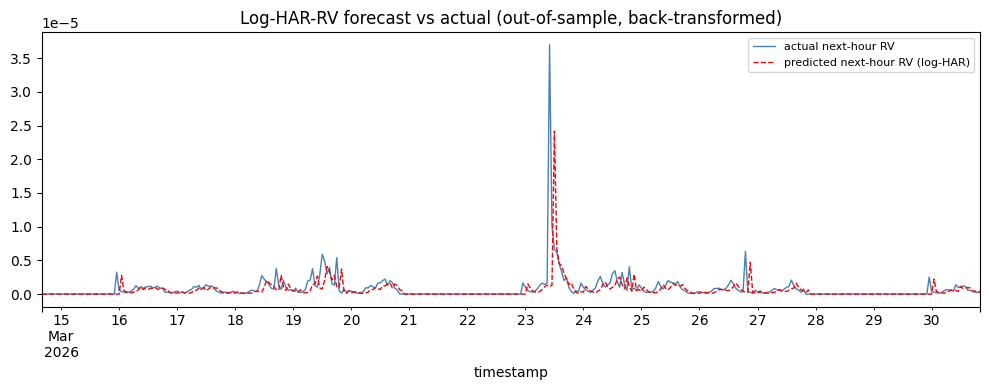

Compare model.params here vs. the raw-level run: coefficients are
now on log-RV, so read them as 'a 1% rise in this lag's variance
is associated with a beta% rise in next-hour variance' -- an
elasticity, not a direct level effect.


In [26]:
"""
Log-HAR-RV: same idea as har_rv_forecast.py, but fit in log-variance space
instead of raw levels. Realized variance is heavy-tailed / roughly
log-normal, so a handful of huge spikes dominate a raw-level OLS fit
(hence the near-flat predictions and low R^2 you got). Logging compresses
the spikes and is the standard fix used in the HAR-RV literature.
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
sq_returns = d['log_return']**2
rv_hourly = sq_returns.resample("1h").sum().dropna()

df = pd.DataFrame({"rv": rv_hourly})
df["rv_lag1"] = df["rv"].shift(1)
df["rv_daily"] = df["rv"].shift(1).rolling(24).mean()
df["rv_weekly"] = df["rv"].shift(1).rolling(24 * 7).mean()
df["rv_target"] = df["rv"].shift(-1)
df = df.dropna()

# ---- log-transform everything (small epsilon guards against log(0)) ------
eps = df["rv"][df["rv"] > 0].min() * 1e-3
for col in ["rv", "rv_lag1", "rv_daily", "rv_weekly", "rv_target"]:
    df[f"log_{col}"] = np.log(df[col] + eps)

split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:]

feature_cols = ["log_rv_lag1", "log_rv_daily", "log_rv_weekly"]
X_train = sm.add_constant(train[feature_cols])
y_train = train["log_rv_target"]
X_test = sm.add_constant(test[feature_cols], has_constant="add")
y_test = test["log_rv_target"]

model = sm.OLS(y_train, X_train).fit()
print(model.summary())
print("\nFitted kernel weights (K), log space:")
print(model.params, "\n")

# ---- out-of-sample R^2, both in log space and back-transformed levels ----
test_pred_log = model.predict(X_test)
ss_res = ((y_test - test_pred_log) ** 2).sum()
ss_tot = ((y_test - y_test.mean()) ** 2).sum()
oos_r2_log = 1 - ss_res / ss_tot

# back-transform to compare against the original raw-level plot
test_pred_level = np.exp(test_pred_log) - eps
y_test_level = np.exp(y_test) - eps
ss_res_lvl = ((y_test_level - test_pred_level) ** 2).sum()
ss_tot_lvl = ((y_test_level - y_test_level.mean()) ** 2).sum()
oos_r2_level = 1 - ss_res_lvl / ss_tot_lvl

print(f"In-sample R^2 (log space):      {model.rsquared:.4f}")
print(f"Out-of-sample R^2 (log space):  {oos_r2_log:.4f}")
print(f"Out-of-sample R^2 (raw levels): {oos_r2_level:.4f}")
print("(compare the raw-levels number directly against your previous run)\n")

# ---- plot: back-transformed predictions vs actual, same scale as before --
fig, ax = plt.subplots(figsize=(10, 4))
y_test_level.plot(ax=ax, label="actual next-hour RV", color="steelblue", lw=1)
test_pred_level.plot(ax=ax, label="predicted next-hour RV (log-HAR)", color="red", lw=1, ls="--")
ax.set_title("Log-HAR-RV forecast vs actual (out-of-sample, back-transformed)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Compare model.params here vs. the raw-level run: coefficients are")
print("now on log-RV, so read them as 'a 1% rise in this lag's variance")
print("is associated with a beta% rise in next-hour variance' -- an")
print("elasticity, not a direct level effect.")

Filtered-return stats:
count    1459.000000
mean       -0.033575
std         0.918031
min        -3.647980
25%        -0.639820
50%        -0.049457
75%         0.583078
max         2.849121
Name: log_return, dtype: float64
mean=-3.357532e-02  var=8.427801e-01



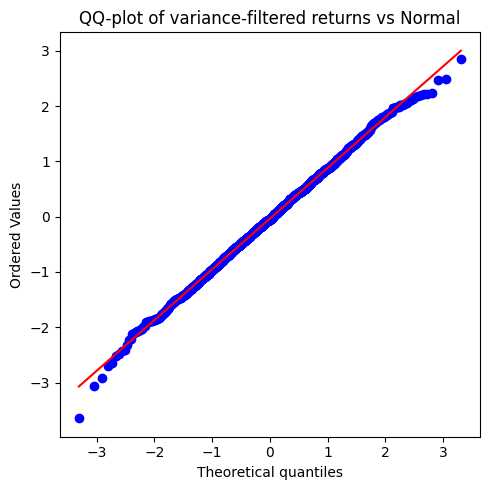

Jarque-Bera: stat=0.635, p=0.7281



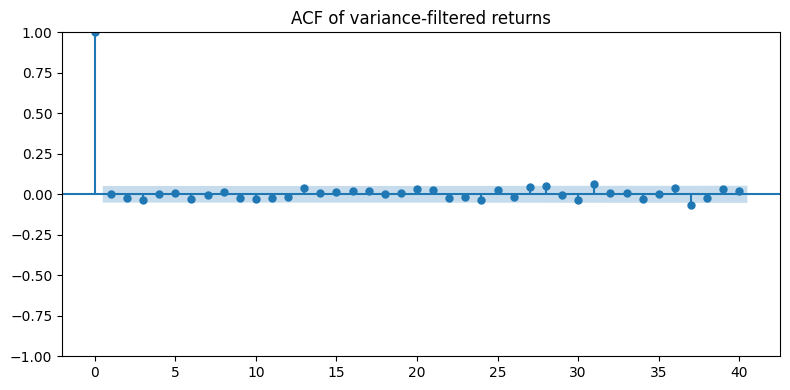

Ljung-Box on filtered returns (raw) -- does direction show up now?
      lb_stat  lb_pvalue
10   6.550713   0.767070
20  13.392642   0.859909
40  46.860721   0.211642 



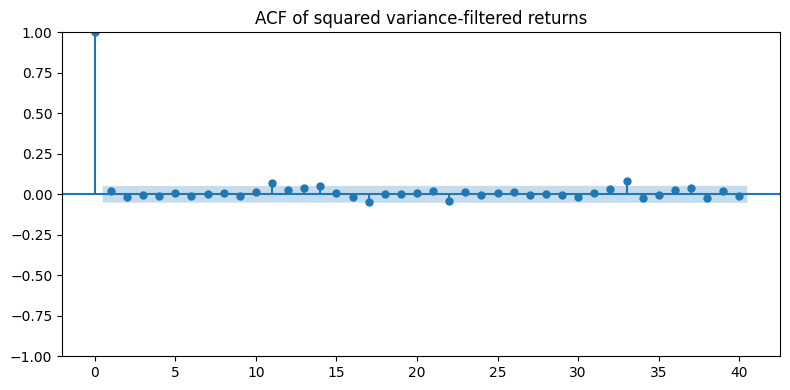

Ljung-Box on squared filtered returns -- want: NOT small (confirms
the volatility clustering was successfully divided out):
      lb_stat  lb_pvalue
10   2.133148   0.995214
20  19.355703   0.498825
40  41.435304   0.407882 



In [29]:
"""
Variance-filtered returns: standardize each hourly return by an estimate
of its local volatility (sigma_hat = sqrt of realized variance for that
hour), then re-run the same ACF/Ljung-Box battery used on B_t earlier.
"""

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

rv_hourly = (d['log_return']**2).resample('1h').sum().dropna()
sigma_hat = np.sqrt(rv_hourly)

ret_hourly = d['log_return'].resample('1h').sum().dropna()
filtered_returns = (ret_hourly / sigma_hat).dropna()

print("Filtered-return stats:")
print(filtered_returns.describe())
print(f"mean={filtered_returns.mean():.6e}  var={filtered_returns.var():.6e}\n")

# QQ-plot + Jarque-Bera
fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(filtered_returns, dist="norm", plot=ax)
ax.set_title("QQ-plot of variance-filtered returns vs Normal")
plt.tight_layout()
plt.show()

jb_stat, jb_p = stats.jarque_bera(filtered_returns)
print(f"Jarque-Bera: stat={jb_stat:.3f}, p={jb_p:.4f}\n")

# ACF of filtered returns -- THE new test
fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(filtered_returns, lags=40, ax=ax)
ax.set_title("ACF of variance-filtered returns")
plt.tight_layout()
plt.show()

lb_raw = acorr_ljungbox(filtered_returns, lags=[10, 20, 40], return_df=True)
print("Ljung-Box on filtered returns (raw) -- does direction show up now?")
print(lb_raw, "\n")

# ACF of squared filtered returns -- sanity check the filtering worked
sq_filtered = filtered_returns**2
fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(sq_filtered, lags=40, ax=ax)
ax.set_title("ACF of squared variance-filtered returns")
plt.tight_layout()
plt.show()

lb_sq = acorr_ljungbox(sq_filtered, lags=[10, 20, 40], return_df=True)
print("Ljung-Box on squared filtered returns -- want: NOT small (confirms")
print("the volatility clustering was successfully divided out):")
print(lb_sq, "\n")

In [30]:
"""
HAR-Filtered: same HAR kernel structure (lag1 + rolling-24h "daily" +
rolling-168h "weekly"), OLS, 80/20 split -- but fit on the variance-
filtered returns z_t = r_t / sigma_hat_t from the cell above instead of
raw signed returns. If the Ljung-Box test above found real autocorrelation
in filtered_returns that wasn't visible in raw returns, this is where
that would translate into an actual forecast improvement.
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

df_z = pd.DataFrame({"z": filtered_returns})
df_z["z_lag1"] = df_z["z"].shift(1)
df_z["z_daily"] = df_z["z"].shift(1).rolling(24).mean()
df_z["z_weekly"] = df_z["z"].shift(1).rolling(24 * 7).mean()
df_z["z_target"] = df_z["z"].shift(-1)
df_z = df_z.dropna()

split_z = int(len(df_z) * 0.8)
train_z, test_z = df_z.iloc[:split_z], df_z.iloc[split_z:]

feature_cols_z = ["z_lag1", "z_daily", "z_weekly"]
X_train_z = sm.add_constant(train_z[feature_cols_z])
y_train_z = train_z["z_target"]
X_test_z = sm.add_constant(test_z[feature_cols_z], has_constant="add")
y_test_z = test_z["z_target"]

model_z = sm.OLS(y_train_z, X_train_z).fit()
print(model_z.summary())
print("\nFitted kernel weights (K), filtered-return space:")
print(model_z.params, "\n")

# ---- out-of-sample R^2 -----------------------------------------------
test_pred_z = model_z.predict(X_test_z)
ss_res_z = ((y_test_z - test_pred_z) ** 2).sum()
ss_tot_z = ((y_test_z - y_test_z.mean()) ** 2).sum()
oos_r2_z = 1 - ss_res_z / ss_tot_z
print(f"In-sample R^2:      {model_z.rsquared:.4f}")
print(f"Out-of-sample R^2:  {oos_r2_z:.4f}\n")

# ---- directional hit rate, same as the HAR-Return check ----------------
pred_sign_z = np.sign(test_pred_z)
actual_sign_z = np.sign(y_test_z)
nonzero_z = actual_sign_z != 0
hit_rate_z = (pred_sign_z[nonzero_z] == actual_sign_z[nonzero_z]).mean()

naive_sign_z = np.sign(test_z["z_lag1"])
naive_hit_rate_z = (naive_sign_z[nonzero_z] == actual_sign_z[nonzero_z]).mean()

print(f"Directional hit rate (HAR-Filtered):        {hit_rate_z:.4f}")
print(f"Directional hit rate (naive, sign(lag1)):   {naive_hit_rate_z:.4f}")
print("(both vs. 0.5 coin-flip baseline)\n")

# ---- the prediction plot -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
y_test_z.plot(ax=ax, label="actual next-hour filtered return", color="steelblue", lw=1)
test_pred_z.plot(ax=ax, label="predicted next-hour filtered return", color="red", lw=1, ls="--")
ax.axhline(0, color="black", lw=0.5)
ax.set_title("HAR forecast vs actual -- variance-filtered returns (out-of-sample)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("har_filtered_forecast.png", dpi=150)
plt.close()

print("Compare model_z.params and R^2/hit-rate here directly against the")
print("HAR-Return cell: any improvement is attributable to filtering out")
print("the time-varying scale before looking for autocorrelation.")


                            OLS Regression Results                            
Dep. Variable:               z_target   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.4533
Date:                Mon, 31 Aug 2026   Prob (F-statistic):              0.715
Time:                        20:38:38   Log-Likelihood:                -1370.6
No. Observations:                1032   AIC:                             2749.
Df Residuals:                    1028   BIC:                             2769.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0181      0.029     -0.628      0.5

Combined (direction x magnitude) out-of-sample R^2: -0.1710
Combined directional hit rate: 0.5352
(compare both against the plain HAR-Return cell's numbers)



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


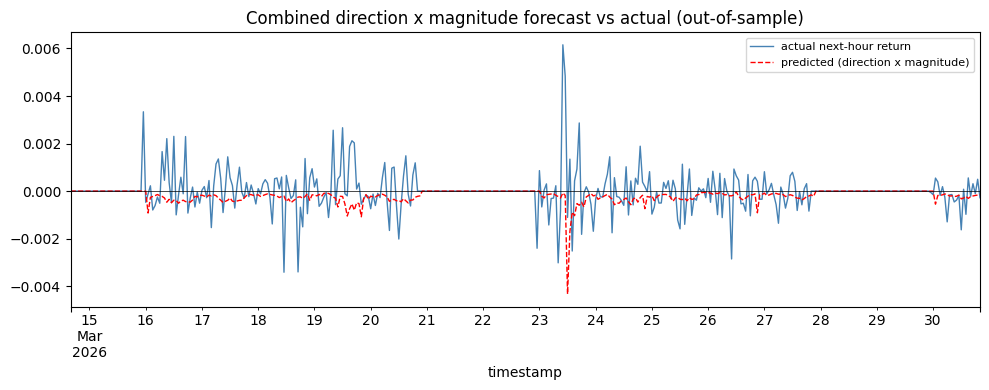

In [34]:
"""
Combined return forecast: r_hat_t = direction_signal_t * magnitude_t

- direction_signal_t: logistic regression's predicted probability of "up",
  rescaled to [-1, 1] (2*p_hat - 1) -- a near-50% call contributes almost
  nothing instead of forcing a full +1/-1 guess.
- magnitude_t: sqrt of the log-HAR-RV model's predicted next-hour
  realized variance, back-transformed from log space.

Both pieces are fit on ONE shared dataframe/train-test split so their
out-of-sample predictions land on exactly the same hours -- no separate
reindexing needed.
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

ret_hourly = d['log_return'].resample('1h').sum().dropna()
rv_hourly = (d['log_return']**2).resample('1h').sum().dropna()

df_comb = pd.DataFrame({"ret": ret_hourly, "rv": rv_hourly})
df_comb["ret_lag1"] = df_comb["ret"].shift(1)
df_comb["ret_daily"] = df_comb["ret"].shift(1).rolling(24).mean()
df_comb["ret_weekly"] = df_comb["ret"].shift(1).rolling(24 * 7).mean()
df_comb["rv_lag1"] = df_comb["rv"].shift(1)
df_comb["rv_daily"] = df_comb["rv"].shift(1).rolling(24).mean()
df_comb["rv_weekly"] = df_comb["rv"].shift(1).rolling(24 * 7).mean()

df_comb["ret_target"] = df_comb["ret"].shift(-1)   # actual next-hour return
df_comb["rv_target"] = df_comb["rv"].shift(-1)      # actual next-hour RV
df_comb["up_target"] = (df_comb["ret_target"] > 0).astype(int)

eps = df_comb["rv"][df_comb["rv"] > 0].min() * 1e-3
for col in ["rv_lag1", "rv_daily", "rv_weekly", "rv_target"]:
    df_comb[f"log_{col}"] = np.log(df_comb[col] + eps)

df_comb = df_comb.dropna()

split = int(len(df_comb) * 0.8)
train, test = df_comb.iloc[:split], df_comb.iloc[split:]

# ---- direction model (logistic regression) ------------------------------
dir_features = ["ret_lag1", "ret_daily", "ret_weekly", "rv_lag1"]
X_train_dir = sm.add_constant(train[dir_features])
X_test_dir = sm.add_constant(test[dir_features], has_constant="add")
logit_model = sm.Logit(train["up_target"], X_train_dir).fit(disp=0)
direction_signal = 2 * logit_model.predict(X_test_dir) - 1

# ---- magnitude model (log-HAR-RV) ----------------------------------------
mag_features = ["log_rv_lag1", "log_rv_daily", "log_rv_weekly"]
X_train_mag = sm.add_constant(train[mag_features])
X_test_mag = sm.add_constant(test[mag_features], has_constant="add")
rv_model = sm.OLS(train["log_rv_target"], X_train_mag).fit()
magnitude_pred = np.sqrt(np.exp(rv_model.predict(X_test_mag)) - eps).clip(lower=0)

# ---- combine ---------------------------------------------------------------
combined_pred_return = direction_signal * magnitude_pred
actual_return = test["ret_target"]

ss_res = ((actual_return - combined_pred_return) ** 2).sum()
ss_tot = ((actual_return - actual_return.mean()) ** 2).sum()
combined_r2 = 1 - ss_res / ss_tot

pred_sign_combined = np.sign(combined_pred_return)
actual_sign = np.sign(actual_return)
nonzero = actual_sign != 0
hit_rate_combined = (pred_sign_combined[nonzero] == actual_sign[nonzero]).mean()

print(f"Combined (direction x magnitude) out-of-sample R^2: {combined_r2:.4f}")
print(f"Combined directional hit rate: {hit_rate_combined:.4f}")
print("(compare both against the plain HAR-Return cell's numbers)\n")

# ---- plot -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
actual_return.plot(ax=ax, label="actual next-hour return", color="steelblue", lw=1)
combined_pred_return.plot(ax=ax, label="predicted (direction x magnitude)", color="red", lw=1, ls="--")
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Combined direction x magnitude forecast vs actual (out-of-sample)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()